In [1]:
import numpy as np
import pandas as pd

In [3]:
import gensim
import os

In [5]:
from nltk import sent_tokenize
from gensim.utils import simple_preprocess

story=[]
for filename in os.listdir('data'):
    if os.path.isfile(os.path.join('data', filename)):
        f=open(os.path.join('data',filename))
        corpus=f.read()
        raw_sent=sent_tokenize(corpus)
        for sent in raw_sent:
            story.append(simple_preprocess(sent))

In [6]:
len(story)

145020

In [7]:
story

[['game',
  'of',
  'thrones',
  'book',
  'one',
  'of',
  'song',
  'of',
  'ice',
  'and',
  'fire',
  'by',
  'george',
  'martin',
  'prologue',
  'we',
  'should',
  'start',
  'back',
  'gared',
  'urged',
  'as',
  'the',
  'woods',
  'began',
  'to',
  'grow',
  'dark',
  'around',
  'them'],
 ['the', 'wildlings', 'are', 'dead'],
 ['do', 'the', 'dead', 'frighten', 'you'],
 ['ser',
  'waymar',
  'royce',
  'asked',
  'with',
  'just',
  'the',
  'hint',
  'of',
  'smile'],
 ['gared', 'did', 'not', 'rise', 'to', 'the', 'bait'],
 ['he',
  'was',
  'an',
  'old',
  'man',
  'past',
  'fifty',
  'and',
  'he',
  'had',
  'seen',
  'the',
  'lordlings',
  'come',
  'and',
  'go'],
 ['dead', 'is', 'dead', 'he', 'said'],
 ['we', 'have', 'no', 'business', 'with', 'the', 'dead'],
 ['are', 'they', 'dead'],
 ['royce', 'asked', 'softly'],
 ['what', 'proof', 'have', 'we'],
 ['will', 'saw', 'them', 'gared', 'said'],
 ['if',
  'he',
  'says',
  'they',
  'are',
  'dead',
  'that',
  'proof',


<h2>Removing Stopwords</h2>

In [18]:
from nltk.corpus import stopwords

In [19]:
def remove_stopwords(text):
    new_text=[]

    for word in text:
        if word not in stopwords.words('english'):
            new_text.append(word)

    return new_text

In [20]:
story=[remove_stopwords(sentence) for sentence in story]

In [21]:
story[0]

['game',
 'thrones',
 'book',
 'one',
 'song',
 'ice',
 'fire',
 'george',
 'martin',
 'prologue',
 'start',
 'back',
 'gared',
 'urged',
 'woods',
 'began',
 'grow',
 'dark',
 'around']

<h3>Building the model</h3>

In [22]:
model=gensim.models.Word2Vec(
    window=10,
    min_count=2
)

In [23]:
#extracting unique words to build my vocabulary
model.build_vocab(story)

In [24]:
#training my Deep Learning model
model.train(story,total_examples=model.corpus_count, epochs=model.epochs)

#total_examples is the total number of sentences in the dataset
#model.epochs is default 5

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


(4396188, 4579390)

<h3>Finding similar words according to model</h3>

In [25]:
model.wv.most_similar('daenerys')

[('stormborn', 0.909748375415802),
 ('unburnt', 0.8948811888694763),
 ('targaryen', 0.8168238997459412),
 ('court', 0.8115197420120239),
 ('viserys', 0.8104087710380554),
 ('elia', 0.8037744164466858),
 ('queen', 0.8021062016487122),
 ('dorne', 0.8011230826377869),
 ('myrcella', 0.8008955121040344),
 ('rhaella', 0.799540102481842)]

<h3>Finding odd one out</h3>

In [26]:
model.wv.doesnt_match(['jon','rikon','robb','arya','sansa','bran'])

'jon'

<p>Here we tried to find the odd one from the stark brothers and sisters. Here Jon is the odd one as he was adopted. This shows how good our model is trained.</p>

In [27]:
model.wv.doesnt_match(['cersei', 'jaime', 'bronn', 'tyrion'])

'bronn'

<h3>Finding similarity between two words</h3>

In [28]:
model.wv.similarity('arya','sansa')
#they are sisters so should have a good similarity

np.float32(0.8001945)

In [15]:
model.wv.similarity('tywin','sansa')
#both are very different so should have a low similarity

np.float32(0.26044917)

<h3>Finding the vectors of any word</h3>

In [29]:
model.wv['king']

array([-0.5569111 , -0.3926462 ,  0.21457303,  1.5244286 , -0.38403362,
       -0.12675624,  0.44488063, -0.94263756, -0.905499  , -0.26752257,
       -0.01256772,  0.6737782 , -0.04224685, -0.01134991, -0.6197218 ,
        1.2571276 ,  1.8292204 ,  0.11624838, -0.62590486, -0.4440152 ,
       -0.4942188 ,  2.284236  , -0.14008233, -4.047058  ,  0.8894412 ,
        0.3975861 , -1.2271662 ,  0.13017267, -1.1490433 ,  1.1343553 ,
       -1.1533601 ,  1.6955127 ,  0.263682  , -0.41062787, -0.7304003 ,
        1.156925  , -0.714195  , -1.523316  , -0.6032012 ,  0.13796645,
        2.02858   , -0.45787957,  0.16427901,  1.046024  ,  1.5415908 ,
       -0.84950656, -1.3338865 , -0.19813143,  2.154596  ,  0.6825243 ,
       -2.3196485 , -0.7749607 ,  2.913128  , -0.43122932, -0.10922898,
        3.8419106 , -0.9742901 ,  1.5489769 , -0.19919692,  3.4507012 ,
        1.822153  ,  0.8009662 , -2.0446496 ,  1.2107875 ,  0.1636782 ,
       -0.20439687, -2.4055798 ,  1.6914085 ,  0.31641272, -1.38

In [30]:
model.wv['king'].shape

(100,)

In [31]:
#getting all vectors in a 2d numpy array
model.wv.get_normed_vectors()

array([[-0.03056975,  0.08826012,  0.04054342, ..., -0.07602905,
        -0.11801649,  0.19892284],
       [-0.20472753,  0.09087192,  0.12536375, ..., -0.11709089,
        -0.11226941,  0.22598189],
       [ 0.01866904,  0.02605506, -0.02038969, ..., -0.12685272,
         0.11696129, -0.16839455],
       ...,
       [-0.04266225,  0.02447723,  0.00350584, ..., -0.10832532,
        -0.00068374,  0.16410904],
       [-0.12244675,  0.08366813,  0.14084923, ..., -0.1095209 ,
         0.13074422,  0.04513208],
       [-0.02406122,  0.06790478,  0.21389674, ...,  0.01246634,
        -0.01421757, -0.05521828]], shape=(17310, 100), dtype=float32)

In [32]:
#getting the meaning of individual vectors
y = model.wv.index_to_key
y

['said',
 'lord',
 'would',
 'one',
 'ser',
 'could',
 'man',
 'king',
 'men',
 'back',
 'well',
 'like',
 'jon',
 'father',
 'old',
 'hand',
 'even',
 'tyrion',
 'never',
 'know',
 'see',
 'made',
 'eyes',
 'black',
 'told',
 'lady',
 'thought',
 'time',
 'long',
 'might',
 'us',
 'come',
 'face',
 'still',
 'head',
 'red',
 'way',
 'boy',
 'page',
 'must',
 'queen',
 'good',
 'two',
 'brother',
 'night',
 'little',
 'took',
 'came',
 'though',
 'say',
 'three',
 'away',
 'dead',
 'son',
 'blood',
 'take',
 'go',
 'half',
 'make',
 'arya',
 'saw',
 'day',
 'white',
 'jaime',
 'first',
 'look',
 'want',
 'much',
 'enough',
 'sword',
 'tell',
 'girl',
 'bran',
 'great',
 'looked',
 'left',
 'knew',
 'asked',
 'gave',
 'maester',
 'called',
 'wall',
 'every',
 'heard',
 'sansa',
 'let',
 'yet',
 'went',
 'turned',
 'dany',
 'need',
 'behind',
 'around',
 'woman',
 'another',
 'snow',
 'beneath',
 'across',
 'knight',
 'keep',
 'grace',
 'found',
 'gold',
 'last',
 'cersei',
 'castle',
 '

<p> said has the vector of the first list in get_normed_vectors() and so on.</p>

<h2>Visualising the Model</h2>

<p>This model has 100 dimensions, to visualise it, we have to use dimensionality reduction techniques and so we use PCA to reduce it to 3 dimensions</p>

In [33]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3)

In [34]:
x=pca.fit_transform(model.wv.get_normed_vectors())

In [35]:
x.shape

(17310, 3)

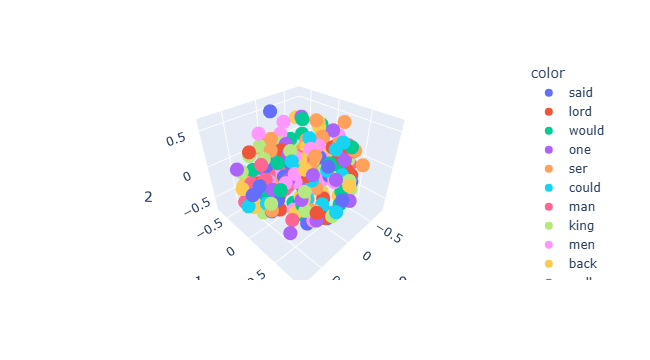

In [38]:
import plotly.express as px
fig = px.scatter_3d(x[:300],x=0,y=1,z=2, color=y[:300])
fig.show()

<p>You can use different parts of the dataset to plot and find interesting relationships and understand the data better.</p>